## Dynamical Low-Rank CG

This notebook tests out the Dynamical Low-Rank Conjugate Gradient (DLR-CG) scheme on some simple problems.
This is the version without any pre-conditioner, as proposed in the thesis.

For the implementation, see `src/algorithms/dynamical_low_rank_cg.py`

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import *
from utils.colors import CMAP
from utils.problem_setup import TestProblemsSetup
from algorithms.cg_solvers import DynamicalLowRankCG

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
setup = TestProblemsSetup(n=64)
problems = setup.get_test_problems(compute_weights=True)

Converged at iter 241 [rel_res=7e-09]250
Converged at iter 230 [rel_res=8.87e-09]
Converged at iter 240 [rel_res=8.94e-09]


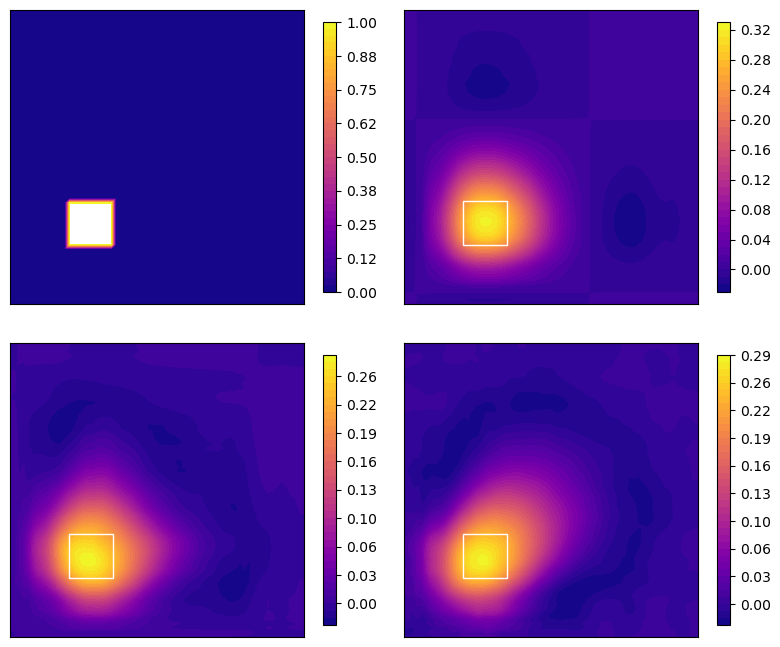

In [3]:
def plot_solutions(f_list, fig_name=None, x0_list=None, y0_list=None, width=0.15, height=0.15):
    import matplotlib.patches as patches
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    axes = axes.flatten()

    for i, (ax, fi) in enumerate(zip(axes, f_list)):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP)

        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.8)
        ax.set_xticks([])
        ax.set_yticks([])
 
        # Plot square
        if i != 0 and x0_list is not None:
            for x0, y0 in zip(x0_list, y0_list):
                square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
                ax.add_patch(square)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.07)
    if fig_name is not None:
        plt.savefig(f'../figures/{fig_name}', dpi=300, bbox_inches='tight')
    plt.show()

    plt.show()

p = problems['I']
solver = DynamicalLowRankCG(p['rsvd'])

f_list = [p['f']]
for mr in [1, 2, 15]:
    x_hat = solver.solve(
        y=p['y'],
        w=p['w'],
        lambda_=(1e-4)**2,
        max_rank=mr,
    )
    f_hat = Function(p['V_h'])
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)


x0_list, y0_list = [0.2], [0.2]
plot_solutions(f_list, x0_list=x0_list, y0_list=y0_list)

---

Converged at iter 179 [rel_res=9.19e-09]
Converged at iter 178 [rel_res=9.29e-09]
Converged at iter 198 [rel_res=9.85e-09]


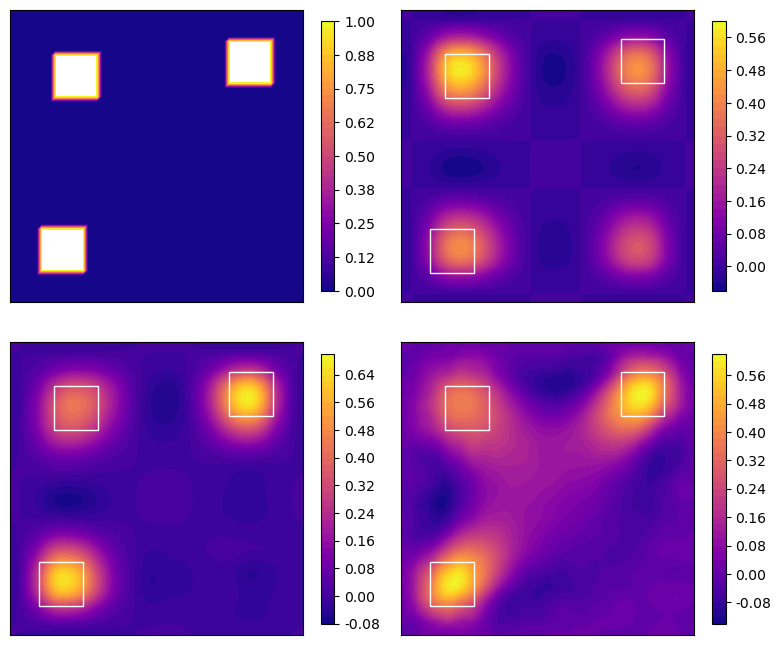

In [4]:
p = problems['II']
solver = DynamicalLowRankCG(p['rsvd'])

f_list = [p['f']]
for mr in [1, 2, 15]:
    x_hat = solver.solve(
        y=p['y'],
        w=p['w'],
        lambda_=(1e-4)**2,
        max_rank=mr,
    )
    f_hat = Function(p['V_h'])
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)

x0_list, y0_list = [0.1, 0.75, 0.15], [0.1, 0.75, 0.70]
plot_solutions(f_list, x0_list=x0_list, y0_list=y0_list)